In [9]:
"""
主题：子图与父图字段不一致时的手动映射方法

学习目标：
  1. 理解为什么需要手动映射（字段名不同、字段结构不同）
  2. 掌握包装节点（Wrapper Node）模式
  3. 学会使用 entry_point 和 output mapping
  4. 了解三种常见的映射场景

核心概念：
  当父子图 State 字段不匹配时，有三种解决方案：

  方案1：包装节点（最常用）
    - 在父图中创建一个普通节点函数
    - 该函数负责转换数据格式后调用子图
    - 将子图输出转换回父图格式

  方案2：修改子图 State 定义
    - 让子图接受更通用的 State
    - 通过可选字段兼容不同父图

  方案3：使用多个子图适配层
    - 为不同的父图创建不同的适配器

前置知识：已完成 18_subgraphs.py
"""

import sys

import io


import os
from typing import TypedDict, Annotated, List
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

load_dotenv()

# 初始化 LLM
llm = ChatAnthropic(model="ppio/pa/claude-sonnet-4-6")

print("=" * 60)
print("LangGraph：子图与父图字段不一致的手动映射")
print("=" * 60)


# ============================================================
# 场景1：字段名不同（最常见）
# ============================================================
print("\n--- 场景1：字段名不同 ---")
print("问题：父图用 'input_text'，子图用 'text'")

# 子图定义：使用 'text' 字段
class SubState_Scene1(TypedDict):
    text: str           # 子图的输入字段名
    translated: str     # 子图的输出字段名


def translate_node_s1(state: SubState_Scene1) -> dict:
    """翻译节点"""
    response = llm.invoke(f"把以下中文翻译成英文，只输出翻译结果：{state['text']}")
    return {"translated": response.content}


# 编译子图
sub_graph_s1 = StateGraph(SubState_Scene1)
sub_graph_s1.add_node("translate", translate_node_s1)
sub_graph_s1.add_edge(START, "translate")
sub_graph_s1.add_edge("translate", END)
subgraph_app_s1 = sub_graph_s1.compile()


# 父图定义：使用 'input_text' 和 'output_text' 字段
class ParentState_Scene1(TypedDict):
    input_text: str     # 父图的输入字段名（与子图不同）
    output_text: str    # 父图的输出字段名（与子图不同）
    status: str         # 父图独有字段


# ✅ 解决方案：包装节点（Wrapper Node）
def translation_wrapper(state: ParentState_Scene1) -> dict:
    """
    包装节点：负责字段映射

    步骤：
    1. 从父图 State 提取数据，转换为子图需要的格式
    2. 调用子图
    3. 将子图输出转换回父图格式
    """
    # Step 1: 构造子图输入（字段名映射）
    subgraph_input = {
        "text": state["input_text"],  # input_text → text
        "translated": ""
    }

    # Step 2: 调用子图
    subgraph_output = subgraph_app_s1.invoke(subgraph_input)

    # Step 3: 转换子图输出为父图格式
    return {
        "output_text": subgraph_output["translated"],  # translated → output_text
        "status": "completed"
    }


# 构建父图
parent_s1 = StateGraph(ParentState_Scene1)
parent_s1.add_node("translate_module", translation_wrapper)  # 使用包装节点
parent_s1.add_edge(START, "translate_module")
parent_s1.add_edge("translate_module", END)
parent_app_s1 = parent_s1.compile()

print("父图 State: {input_text, output_text, status}")
print("子图 State: {text, translated}")
print("映射关系: input_text → text, translated → output_text")

result_s1 = parent_app_s1.invoke({
    "input_text": "深度学习很强大",
    "output_text": "",
    "status": ""
})

print(f"\n[测试结果]")
print(f"  输入：{result_s1['input_text']}")
print(f"  输出：{result_s1['output_text']}")
print(f"  状态：{result_s1['status']}")


# ============================================================
# 场景2：字段结构不同（嵌套 vs 扁平）
# ============================================================
print("\n--- 场景2：字段结构不同 ---")
print("问题：父图用嵌套结构，子图用扁平结构")

# 子图定义：扁平结构
class SubState_Scene2(TypedDict):
    query: str          # 简单字符串
    answer: str         # 简单字符串


def answer_node_s2(state: SubState_Scene2) -> dict:
    """回答节点"""
    response = llm.invoke(f"简洁回答：{state['query']}")
    return {"answer": response.content}


sub_graph_s2 = StateGraph(SubState_Scene2)
sub_graph_s2.add_node("answer", answer_node_s2)
sub_graph_s2.add_edge(START, "answer")
sub_graph_s2.add_edge("answer", END)
subgraph_app_s2 = sub_graph_s2.compile()


# 父图定义：嵌套结构
class QuestionData(TypedDict):
    content: str
    category: str


class ParentState_Scene2(TypedDict):
    question: QuestionData      # 嵌套对象
    response_data: dict         # 字典结构
    metadata: dict


def qa_wrapper(state: ParentState_Scene2) -> dict:
    """
    包装节点：处理嵌套结构映射

    从嵌套结构中提取数据，调用子图，再组装回嵌套结构
    """
    # Step 1: 从嵌套结构中提取子图需要的字段
    subgraph_input = {
        "query": state["question"]["content"],  # 从嵌套对象中提取
        "answer": ""
    }

    # Step 2: 调用子图
    subgraph_output = subgraph_app_s2.invoke(subgraph_input)

    # Step 3: 组装回嵌套结构
    return {
        "response_data": {
            "answer": subgraph_output["answer"],
            "timestamp": "2026-06-08"
        },
        "metadata": {
            "category": state["question"]["category"],
            "processed": True
        }
    }


parent_s2 = StateGraph(ParentState_Scene2)
parent_s2.add_node("qa_module", qa_wrapper)
parent_s2.add_edge(START, "qa_module")
parent_s2.add_edge("qa_module", END)
parent_app_s2 = parent_s2.compile()

print("父图 State: {question: {content, category}, response_data: dict, metadata: dict}")
print("子图 State: {query: str, answer: str}")
print("映射：从嵌套结构提取 content → query")

result_s2 = parent_app_s2.invoke({
    "question": {"content": "Python是什么？", "category": "tech"},
    "response_data": {},
    "metadata": {}
})

print(f"\n[测试结果]")
print(f"  问题：{result_s2['question']['content']}")
print(f"  回答：{result_s2['response_data']['answer'][:50]}...")
print(f"  元数据：{result_s2['metadata']}")


# ============================================================
# 场景3：一对多映射（一个父图字段对应多个子图字段）
# ============================================================
print("\n--- 场景3：一对多映射 ---")
print("问题：父图一个字段需要拆分给子图多个字段")

# 子图定义：需要多个独立字段
class SubState_Scene3(TypedDict):
    title: str          # 标题
    content: str        # 内容
    summary: str        # 摘要


def process_document_s3(state: SubState_Scene3) -> dict:
    """文档处理节点"""
    response = llm.invoke(
        f"为以下文档生成一句话摘要：\n标题：{state['title']}\n内容：{state['content']}"
    )
    return {"summary": response.content}


sub_graph_s3 = StateGraph(SubState_Scene3)
sub_graph_s3.add_node("process", process_document_s3)
sub_graph_s3.add_edge(START, "process")
sub_graph_s3.add_edge("process", END)
subgraph_app_s3 = sub_graph_s3.compile()


# 父图定义：文档作为一个整体对象
class Document(TypedDict):
    title: str
    content: str
    author: str


class ParentState_Scene3(TypedDict):
    document: Document      # 整个文档对象
    result_summary: str     # 处理结果


def document_processor_wrapper(state: ParentState_Scene3) -> dict:
    """
    包装节点：将一个对象拆分为多个字段

    从 document 对象中提取 title 和 content，分别传给子图
    """
    # Step 1: 拆分对象为多个字段
    doc = state["document"]
    subgraph_input = {
        "title": doc["title"],
        "content": doc["content"],
        "summary": ""
    }

    # Step 2: 调用子图
    subgraph_output = subgraph_app_s3.invoke(subgraph_input)

    # Step 3: 返回结果
    return {"result_summary": subgraph_output["summary"]}


parent_s3 = StateGraph(ParentState_Scene3)
parent_s3.add_node("doc_processor", document_processor_wrapper)
parent_s3.add_edge(START, "doc_processor")
parent_s3.add_edge("doc_processor", END)
parent_app_s3 = parent_s3.compile()

print("父图 State: {document: {title, content, author}, result_summary}")
print("子图 State: {title, content, summary}")
print("映射：document.title → title, document.content → content")

result_s3 = parent_app_s3.invoke({
    "document": {
        "title": "人工智能简介",
        "content": "人工智能是模拟人类智能的技术...",
        "author": "张三"
    },
    "result_summary": ""
})

print(f"\n[测试结果]")
print(f"  标题：{result_s3['document']['title']}")
print(f"  摘要：{result_s3['result_summary'][:50]}...")


# ============================================================
# 场景4：多子图串联（每个子图有不同的 State）
# ============================================================
print("\n--- 场景4：多子图串联 ---")
print("问题：多个子图字段各不相同，需要在父图中统一协调")

# 子图1：翻译
class TranslateSubState(TypedDict):
    text: str
    translated: str


def translate_node_s4(state: TranslateSubState) -> dict:
    response = llm.invoke(f"翻译成英文：{state['text']}")
    return {"translated": response.content}


translate_sub = StateGraph(TranslateSubState)
translate_sub.add_node("translate", translate_node_s4)
translate_sub.add_edge(START, "translate")
translate_sub.add_edge("translate", END)
translate_app = translate_sub.compile()


# 子图2：润色
class PolishSubState(TypedDict):
    input_text: str       # 注意：字段名与翻译子图不同
    polished_text: str


def polish_node_s4(state: PolishSubState) -> dict:
    response = llm.invoke(f"润色以下英文，使其更流畅：{state['input_text']}")
    return {"polished_text": response.content}


polish_sub = StateGraph(PolishSubState)
polish_sub.add_node("polish", polish_node_s4)
polish_sub.add_edge(START, "polish")
polish_sub.add_edge("polish", END)
polish_app = polish_sub.compile()


# 父图：协调两个子图
class ParentState_Scene4(TypedDict):
    original: str
    translated: str
    final: str


def translate_wrapper_s4(state: ParentState_Scene4) -> dict:
    """翻译包装节点"""
    result = translate_app.invoke({
        "text": state["original"],
        "translated": ""
    })
    return {"translated": result["translated"]}


def polish_wrapper_s4(state: ParentState_Scene4) -> dict:
    """润色包装节点：需要将 translated 映射为 input_text"""
    result = polish_app.invoke({
        "input_text": state["translated"],  # 字段名映射
        "polished_text": ""
    })
    return {"final": result["polished_text"]}


parent_s4 = StateGraph(ParentState_Scene4)
parent_s4.add_node("translate", translate_wrapper_s4)
parent_s4.add_node("polish", polish_wrapper_s4)
parent_s4.add_edge(START, "translate")
parent_s4.add_edge("translate", "polish")
parent_s4.add_edge("polish", END)
parent_app_s4 = parent_s4.compile()

print("翻译子图 State: {text, translated}")
print("润色子图 State: {input_text, polished_text}")
print("父图 State: {original, translated, final}")
print("映射链：original → text → translated → input_text → final")

result_s4 = parent_app_s4.invoke({
    "original": "机器学习很重要",
    "translated": "",
    "final": ""
})

print(f"\n[测试结果]")
print(f"  原文：{result_s4['original']}")
print(f"  翻译：{result_s4['translated'][:50]}...")
print(f"  润色：{result_s4['final'][:50]}...")


D:\claude_project\claude_study\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


LangGraph：子图与父图字段不一致的手动映射

--- 场景1：字段名不同 ---
问题：父图用 'input_text'，子图用 'text'
父图 State: {input_text, output_text, status}
子图 State: {text, translated}
映射关系: input_text → text, translated → output_text

[测试结果]
  输入：深度学习很强大
  输出：Deep learning is very powerful.
  状态：completed

--- 场景2：字段结构不同 ---
问题：父图用嵌套结构，子图用扁平结构
父图 State: {question: {content, category}, response_data: dict, metadata: dict}
子图 State: {query: str, answer: str}
映射：从嵌套结构提取 content → query

[测试结果]
  问题：Python是什么？
  回答：## Python 简介

Python 是一种**高级、通用、解释型**编程语言，由 Guido ...
  元数据：{'category': 'tech', 'processed': True}

--- 场景3：一对多映射 ---
问题：父图一个字段需要拆分给子图多个字段
父图 State: {document: {title, content, author}, result_summary}
子图 State: {title, content, summary}
映射：document.title → title, document.content → content

[测试结果]
  标题：人工智能简介
  摘要：## 一句话摘要

人工智能是一种旨在模拟和复现人类智能行为的技术领域。...

--- 场景4：多子图串联 ---
问题：多个子图字段各不相同，需要在父图中统一协调
翻译子图 State: {text, translated}
润色子图 State: {input_text, polished_text}
父图 State: {original, translated, final}
映射链：o

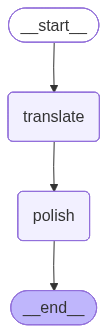

In [10]:
from IPython.display import Image, display
display(Image(parent_app_s4.get_graph().draw_mermaid_png()))

In [ ]:
# ============================================================
# 总结
# ============================================================
def main():
    print("\n" + "=" * 60)
    print("总结：手动映射的三种模式")
    print("=" * 60)
    print("""
1️⃣  包装节点模式（最常用）：
   def wrapper_node(parent_state):
       # 1. 构造子图输入
       sub_input = {"sub_field": parent_state["parent_field"]}

       # 2. 调用子图
       sub_output = subgraph_app.invoke(sub_input)

       # 3. 转换输出
       return {"parent_result": sub_output["sub_result"]}

   优点：灵活、清晰、易测试
   缺点：需要编写额外的包装代码

2️⃣  修改子图 State：
   - 让子图使用更通用的字段名
   - 添加可选字段兼容不同父图

   优点：减少包装代码
   缺点：子图耦合度增加

3️⃣  多层适配：
   - 为不同的父图创建不同的适配器
   - 适配器负责特定的字段映射

   优点：解耦、可复用
   缺点：代码量增加

📌 最佳实践：
   • 优先使用包装节点模式（清晰可控）
   • 字段映射逻辑集中在包装函数中
   • 为包装函数编写单元测试
   • 文档化字段映射关系
    """)


if __name__ == "__main__":
    main()